In [3]:
import numpy as np
import matplotlib.pyplot as plt

iris = np.genfromtxt("iris_1D.csv", delimiter=',', skip_header=1)

X = iris[:, :1]
print(f"X: {X.shape}")
y = iris[:, 1]
print(f"y: {y.shape}")
N = 6

intercept = np.ones((X.shape[0], 1))
print(f"intercept: {intercept.shape}")
X = np.concatenate((intercept, X), axis=1)
print(f"X: {X.shape}")
print(X)

X: (6, 1)
y: (6,)
intercept: (6, 1)
X: (6, 2)
[[1.  1.4]
 [1.  1. ]
 [1.  1.5]
 [1.  3.1]
 [1.  3.8]
 [1.  4.1]]


In [4]:
# Shuffle
idx = np.arange(X.shape[0])
print(f"inds: {idx.shape}")
print(f"inds: {idx}")
np.random.shuffle(idx)

X = X[idx]
print(f"X: {X.shape}")
y = y[idx]
print(f"y: {y.shape}")

inds: (6,)
inds: [0 1 2 3 4 5]
X: (6, 2)
y: (6,)


In [5]:
def sigmoid_function(z):
    return 1/(1+np.exp(-z))

def predict(x, theta):
    y_hat = sigmoid_function(np.dot(x, theta))
    return y_hat

def loss_function(y_hat, y):
    return (y_hat - y)**2

def compute_gradient(x, y_hat, y):
    return 2*x*(y_hat - y)*y_hat*(1-y_hat)

In [6]:
lr = 0.31
num_iter = 5000

theta = np.array([0.1, 5])
losses = []
accs = []
for _ in range(num_iter):
    for i in range(N):
        xi = X[i]
        yi = y[i]
        y_hat = predict(xi, theta)
        loss = loss_function(y_hat, yi)
        gradient = compute_gradient(xi, y_hat, yi)
        theta -= lr*gradient
        losses.append(loss)
    preds = predict(X, theta).round()
    acc = (preds==y).mean()
    accs.append(acc)

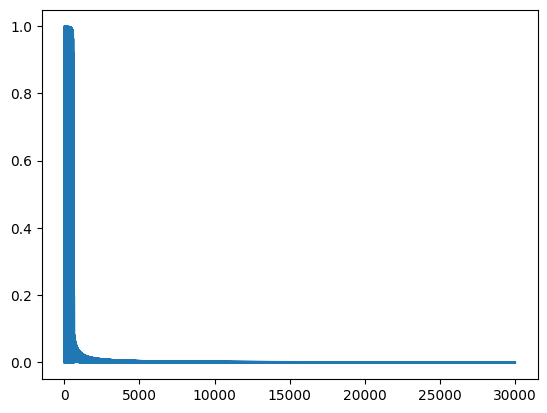

In [7]:
plt.plot(losses)
plt.show()

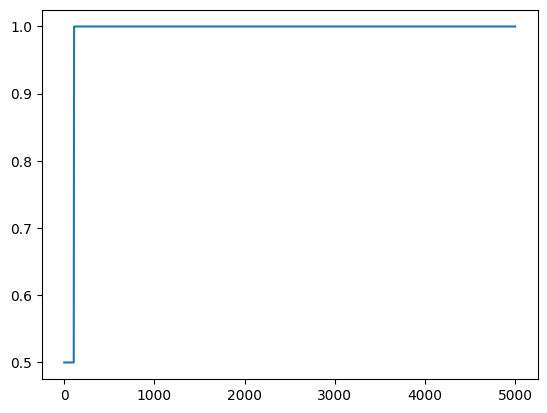

In [8]:
plt.plot(accs)
plt.show()

In [9]:
preds = predict(X, theta).round()
print(preds)
print(y)

[1. 1. 0. 0. 0. 1.]
[1. 1. 0. 0. 0. 1.]
